## Tidal Decomposition of Nain Bay ADCP data from ALS

In [53]:
# Import the required libraries
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utide
from utide._solve import solve
from matplotlib.dates import date2num

In [39]:
# Load the processed data files

df = pd.read_csv("data/processed/near_surf.csv")

# set the latitiude used in the analysis
lat =  56.54195 

In [40]:
print(df.head())

              datetime  direction  umajor  uminor  veast  vnorth  speed  \
0  2020-02-15 19:52:00      71.48   12.40    0.23  11.76    3.94  12.40   
1  2020-02-15 20:22:00      55.69   13.12   -3.45  11.21    7.65  13.57   
2  2020-02-15 20:52:00      56.01    9.75   -2.51   8.35    5.63  10.07   
3  2020-02-15 21:22:00      51.71    7.97   -2.70   6.60    5.21   8.41   
4  2020-02-15 21:52:00      83.16    2.46    0.56   2.50    0.30   2.52   

      Source  
0  near_surf  
1  near_surf  
2  near_surf  
3  near_surf  
4  near_surf  


In [41]:
# convert columns with date/time information to datetime object
df["datetime"] = pd.to_datetime(df["datetime"])

# use the datetime object as index
df = df.set_index("datetime")
print(df.head())

                     direction  umajor  uminor  veast  vnorth  speed  \
datetime                                                               
2020-02-15 19:52:00      71.48   12.40    0.23  11.76    3.94  12.40   
2020-02-15 20:22:00      55.69   13.12   -3.45  11.21    7.65  13.57   
2020-02-15 20:52:00      56.01    9.75   -2.51   8.35    5.63  10.07   
2020-02-15 21:22:00      51.71    7.97   -2.70   6.60    5.21   8.41   
2020-02-15 21:52:00      83.16    2.46    0.56   2.50    0.30   2.52   

                        Source  
datetime                        
2020-02-15 19:52:00  near_surf  
2020-02-15 20:22:00  near_surf  
2020-02-15 20:52:00  near_surf  
2020-02-15 21:22:00  near_surf  
2020-02-15 21:52:00  near_surf  


In [67]:
# Select the columns of interest
df_subset = df[['veast', 'vnorth']]

# Find zeros and NaNs in the 'veast' and 'vnorth' columns
zeros = (df_subset == 0)
nans = df_subset.isna()

# Find the indices of zeros and NaNs
indices = zeros.stack().loc[lambda x: x].index

There aren't NaNs in the data, but several instances of 'zeros' which breaks the utide analysis. 

In [70]:
# Replace zeros with a small number (1e-6)
df['veast'] = df['veast'].replace(0, 1e-6)
df['vnorth'] = df['vnorth'].replace(0, 1e-6)

## Tidal Analysis¶

Following procedure in: https://nbviewer.org/github/wesleybowman/UTide/blob/master/notebooks/utide_uv_example.ipynb

In [71]:
time = date2num(df.index.to_pydatetime())
time_series_u = df['veast']
time_series_v = df['vnorth']

coef = solve(
    time,
    time_series_u,
    time_series_v,
    lat=30,
    nodal=False,
    trend=False,
    method="ols",
    conf_int="linear",
    Rayleigh_min=0.95,
)

solve: matrix prep ... solution ... done.


In [73]:
from utide import reconstruct

tide = reconstruct(time, coef)

prep/calcs ... done.


In [74]:
tide.keys()

dict_keys(['t_in', 'epoch', 'constit', 'min_SNR', 'min_PE', 't_mpl', 'u', 'v'])

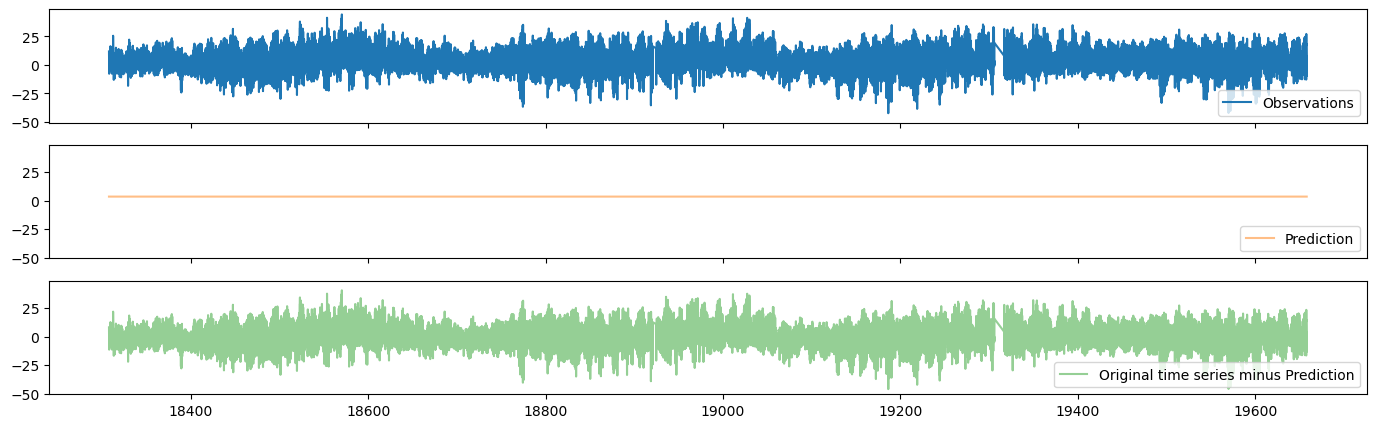

In [79]:
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, sharey=True, sharex=True, figsize=(17, 5))

ax0.plot(time, time_series_u, label='Observations', color='C0')
ax0.legend(numpoints=1, loc='lower right')

ax1.plot(time, tide['u'], alpha=0.5, label='Prediction', color='C1')
ax1.legend(numpoints=1, loc='lower right')

ax2.plot(time, time_series_u-tide['u'], alpha=0.5, label='Original time series minus Prediction', color='C2')
ax2.legend(numpoints=1, loc='lower right');

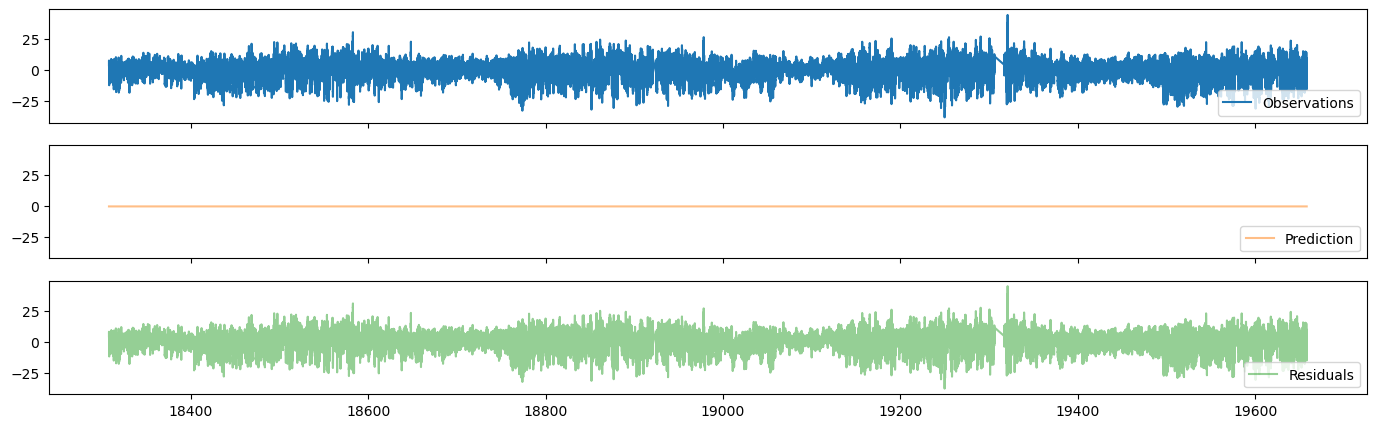

In [82]:
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, sharey=True, sharex=True, figsize=(17, 5))

ax0.plot(time, time_series_v, label='Observations', color='C0')
ax0.legend(numpoints=1, loc='lower right')

ax1.plot(time, tide['v'], alpha=0.5, label='Prediction', color='C1')
ax1.legend(numpoints=1, loc='lower right')

ax2.plot(time, time_series_v-tide['v'], alpha=0.5, label='Residuals', color='C2')
ax2.legend(numpoints=1, loc='lower right');

In [84]:
print(coef)

Lsmaj    :                                       []
Lsmaj_ci :                                       []
Lsmin    :                                       []
Lsmin_ci :                                       []
PE       :                                       []
SNR      :                                       []
aux      : frq     :                                       []
lat     :                                       30
lind    :                                       []
opt     : RunTimeDisp :                                     True
cnstit      :                                     auto
conf_int    :                                     True
diagnminsnr :                                        2
diagnplots  :                                        0
epoch       :                                     None
equi        :                                    False
gwchlint    :                                    False
gwchnone    :                                    False
infer       :      